In [1]:
import numpy as np 
import pandas as pd 
import math
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn import metrics
from sklearn import svm
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.dummy import DummyClassifier
from imblearn.metrics import geometric_mean_score

In [2]:
data=pd.read_csv("hayes-roth.csv")

In [3]:
import sklearn
sklearn.__version__

'1.0.2'

In [4]:
data.columns=["id","Oxin","Onine","Hormone","Tsh","Resin","Class"]

In [5]:
data.set_index("id", inplace=True)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 131 entries, 2 to 132
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Oxin     131 non-null    int64
 1   Onine    131 non-null    int64
 2   Hormone  131 non-null    int64
 3   Tsh      131 non-null    int64
 4   Resin    131 non-null    int64
 5   Class    131 non-null    int64
dtypes: int64(6)
memory usage: 7.2 KB


In [7]:
data

,Oxin,Onine,Hormone,Tsh,Resin,Class
id,,,,,,
2,10,2,1,3,2,2
3,83,3,1,4,1,3
4,61,2,4,2,2,3
5,107,1,1,3,4,3
6,113,1,1,3,2,2
...,...,...,...,...,...,...
128,44,1,1,4,3,3
129,40,2,1,2,1,1
130,90,1,2,1,2,2


In [8]:
gb=data.groupby("Class")

In [9]:
for Class, Class_df in gb:
    print(Class)
    print(Class_df)

1
     Oxin  Onine  Hormone  Tsh  Resin  Class
id                                          
9      36      2        2    1      1      1
10    105      3        2    1      1      1
11     81      1        2    1      1      1
13     94      1        1    2      1      1
16     20      1        1    3      3      1
18     50      1        2    1      1      1
19     68      3        3    2      1      1
20     89      3        1    3      2      1
22     19      3        2    1      3      1
23    118      2        1    2      1      1
24     16      3        2    1      3      1
25     91      2        3    2      1      1
29     30      1        1    3      2      1
30     57      3        2    1      1      1
32    114      2        2    1      3      1
34     66      1        1    1      2      1
44     74      3        2    1      1      1
45    106      3        1    2      1      1
47    130      2        1    1      2      1
48     54      1        1    1      2      1
50     6

In [10]:
gb.get_group(1)

,Oxin,Onine,Hormone,Tsh,Resin,Class
id,,,,,,
9,36,2,2,1,1,1
10,105,3,2,1,1,1
11,81,1,2,1,1,1
13,94,1,1,2,1,1
16,20,1,1,3,3,1
18,50,1,2,1,1,1
19,68,3,3,2,1,1
20,89,3,1,3,2,1
22,19,3,2,1,3,1


In [11]:
class_samples=gb.get_group(1).sample(n=15)
#    print(class_samples)

In [12]:
print(type(class_samples))

<class 'pandas.core.frame.DataFrame'>


In [13]:
mean_sum=class_samples["Oxin"].mean() + class_samples["Onine"].mean() + class_samples["Hormone"].mean() + class_samples["Tsh"].mean() + class_samples["Resin"].mean()

In [14]:
column_length=len(data.columns) -1

In [15]:
similar_val_1=mean_sum/column_length
print(similar_val_1)

14.826666666666664


In [16]:
class_2_samples=gb.get_group(2).sample(n=15)
#    print(class_2_samples)

In [17]:
mean_sum_2=class_2_samples["Oxin"].mean() + class_2_samples["Onine"].mean() + class_2_samples["Hormone"].mean() + class_2_samples["Tsh"].mean() + class_2_samples["Resin"].mean()

In [18]:
similar_val_2=mean_sum_2/column_length
print(similar_val_2)

14.279999999999998


In [19]:
class_3_samples=gb.get_group(3).sample(n=15)
#    print(class_3_samples)

In [20]:
mean_sum_3=class_3_samples["Oxin"].mean() + class_3_samples["Onine"].mean() + class_3_samples["Hormone"].mean() + class_3_samples["Tsh"].mean() + class_3_samples["Resin"].mean()

In [21]:
similar_val_3=mean_sum_3/column_length
print(similar_val_3)

13.813333333333333


In [22]:
sim_23=similar_val_3 - similar_val_2
sim_23=sim_23/100
sim_23=1 - sim_23
sim_12=similar_val_1 - similar_val_2
sim_12=sim_12/100
sim_12=1 - sim_12
sim_13=similar_val_3 - similar_val_1
sim_13=sim_13/100
sim_13=1 - sim_13

print("Similarity between 2 and 3: ", sim_23)
print("Similarity between 2 and 1: ", sim_12)
print("Similarity between 1 and 3: ", sim_13)

Similarity between 2 and 3:  1.0046666666666666
Similarity between 2 and 1:  0.9945333333333334
Similarity between 1 and 3:  1.0101333333333333


In [23]:
gb.size()

Class
1    50
2    51
3    30
dtype: int64

In [24]:
m=math.ceil((50+30)/2)

In [25]:
print(m)

40


In [26]:
len(gb)

3

In [27]:
neigh = KNeighborsClassifier(n_neighbors=5)

In [28]:
#neigh.fit(X_train, Y_train)
neigh.fit(data, data.Class)

KNeighborsClassifier()

In [29]:
result=neigh.kneighbors(data, return_distance=True)

In [30]:
print(type(result))

<class 'tuple'>


In [31]:
print(result)

(array([[0.        , 2.23606798, 2.64575131, 4.        , 4.12310563],
       [0.        , 2.82842712, 3.46410162, 4.        , 4.12310563],
       [0.        , 3.16227766, 3.31662479, 3.31662479, 3.46410162],
       [0.        , 3.46410162, 3.87298335, 3.87298335, 4.35889894],
       [0.        , 2.64575131, 3.        , 3.16227766, 3.31662479],
       [0.        , 2.        , 2.44948974, 3.46410162, 3.46410162],
       [0.        , 2.64575131, 3.87298335, 4.69041576, 4.79583152],
       [0.        , 2.44948974, 2.44948974, 2.64575131, 3.46410162],
       [0.        , 1.73205081, 2.23606798, 3.        , 3.87298335],
       [0.        , 1.73205081, 3.16227766, 3.46410162, 3.46410162],
       [0.        , 3.16227766, 3.46410162, 3.74165739, 3.87298335],
       [0.        , 1.41421356, 2.44948974, 2.44948974, 3.31662479],
       [0.        , 2.        , 2.23606798, 2.64575131, 3.31662479],
       [0.        , 3.31662479, 4.24264069, 4.35889894, 4.35889894],
       [0.        , 2.82842712, 3

In [32]:
arr1=result[0]

In [33]:
print(type(arr1))

<class 'numpy.ndarray'>


In [34]:
print(arr1.ndim)

2


In [35]:
arr2=result[1]

In [36]:
print(type(arr2))

<class 'numpy.ndarray'>


In [37]:
print(arr1.ndim)

2


In [38]:
print(arr2)

[[  0  59 130 118 109]
 [  1  39   5  15  37]
 [  2  89  12  38  80]
 [  3  85  68  78  43]
 [  4  87  30  44  99]
 [  5  24  58   9  36]
 [  6 117  10  61 112]
 [  7  82  88  31  50]
 [  8  43 108  68  78]
 [  9  37  24   5  39]
 [ 10  54 117  81   6]
 [ 11  75  53  64 100]
 [ 12  93  80 104   2]
 [ 13  41 125 130 109]
 [ 14 129  20  79  97]
 [ 15  40  39  37  35]
 [ 16 101  19 102  51]
 [ 17  49  48  55  32]
 [ 18  35  23 128 103]
 [ 19  16  51  46 102]
 [ 20 124  22  14 129]
 [ 21  72  34  91  81]
 [ 22 124  20 111 119]
 [ 23 128  75  18  11]
 [ 24  36  58   5  94]
 [ 25  26 116 129  97]
 [ 26  66 116  25  96]
 [ 27  96 105  98  86]
 [ 28  92 104  93  12]
 [ 29  62  63  95  70]
 [ 30  44  87  34   4]
 [ 31  82 120   7  50]
 [ 32  90  48  17  89]
 [ 33  99  85  78   4]
 [ 34  21  44  30  91]
 [ 35 128  40  18 103]
 [ 36  94  58  24  42]
 [ 37   9  39   5  15]
 [ 38  90  89   2  80]
 [ 39  15  40  37   1]
 [ 40  15  39  35 103]
 [ 41 109  13  62 130]
 [ 42  65  94  36 121]
 [ 43   8  

In [39]:
print(arr1)

[[0.         2.23606798 2.64575131 4.         4.12310563]
 [0.         2.82842712 3.46410162 4.         4.12310563]
 [0.         3.16227766 3.31662479 3.31662479 3.46410162]
 [0.         3.46410162 3.87298335 3.87298335 4.35889894]
 [0.         2.64575131 3.         3.16227766 3.31662479]
 [0.         2.         2.44948974 3.46410162 3.46410162]
 [0.         2.64575131 3.87298335 4.69041576 4.79583152]
 [0.         2.44948974 2.44948974 2.64575131 3.46410162]
 [0.         1.73205081 2.23606798 3.         3.87298335]
 [0.         1.73205081 3.16227766 3.46410162 3.46410162]
 [0.         3.16227766 3.46410162 3.74165739 3.87298335]
 [0.         1.41421356 2.44948974 2.44948974 3.31662479]
 [0.         2.         2.23606798 2.64575131 3.31662479]
 [0.         3.31662479 4.24264069 4.35889894 4.35889894]
 [0.         2.82842712 3.16227766 3.31662479 3.74165739]
 [0.         1.41421356 2.         3.60555128 3.87298335]
 [0.         1.73205081 2.44948974 2.64575131 3.87298335]
 [0.         1

In [40]:
#print(arr1)

In [41]:
print(arr1.size)

655


In [42]:
addVal=[]
s=1
for i in arr1:
    _sum=int(i[0] + i[1] + i[2] + i[3] + i[4])
    addVal.append(_sum)
    print(i ," ", _sum, " ") 
    s=s+1

[0.         2.23606798 2.64575131 4.         4.12310563]   13  
[0.         2.82842712 3.46410162 4.         4.12310563]   14  
[0.         3.16227766 3.31662479 3.31662479 3.46410162]   13  
[0.         3.46410162 3.87298335 3.87298335 4.35889894]   15  
[0.         2.64575131 3.         3.16227766 3.31662479]   12  
[0.         2.         2.44948974 3.46410162 3.46410162]   11  
[0.         2.64575131 3.87298335 4.69041576 4.79583152]   16  
[0.         2.44948974 2.44948974 2.64575131 3.46410162]   11  
[0.         1.73205081 2.23606798 3.         3.87298335]   10  
[0.         1.73205081 3.16227766 3.46410162 3.46410162]   11  
[0.         3.16227766 3.46410162 3.74165739 3.87298335]   14  
[0.         1.41421356 2.44948974 2.44948974 3.31662479]   9  
[0.         2.         2.23606798 2.64575131 3.31662479]   10  
[0.         3.31662479 4.24264069 4.35889894 4.35889894]   16  
[0.         2.82842712 3.16227766 3.31662479 3.74165739]   13  
[0.         1.41421356 2.         3.60555

In [43]:
print(len(addVal))

131


In [44]:
print(addVal)

[13, 14, 13, 15, 12, 11, 16, 11, 10, 11, 14, 9, 10, 16, 13, 10, 10, 9, 12, 10, 12, 9, 12, 12, 9, 13, 9, 12, 11, 14, 10, 10, 13, 14, 11, 10, 8, 11, 12, 9, 9, 13, 11, 11, 10, 10, 11, 10, 10, 9, 11, 10, 11, 11, 9, 10, 11, 12, 9, 13, 10, 15, 12, 15, 11, 10, 10, 14, 12, 14, 15, 12, 9, 17, 13, 10, 14, 13, 13, 15, 11, 9, 9, 16, 10, 13, 10, 11, 9, 11, 11, 12, 10, 10, 9, 16, 11, 15, 11, 11, 11, 11, 11, 13, 10, 9, 14, 15, 12, 12, 10, 12, 11, 15, 16, 12, 11, 12, 13, 12, 13, 10, 13, 12, 11, 16, 15, 11, 11, 13, 13]


In [45]:
arr3=np.array(addVal)

In [46]:
print(type(arr3))

<class 'numpy.ndarray'>


In [47]:
print(arr3.size)

131


In [48]:
print(arr3)

[13 14 13 15 12 11 16 11 10 11 14  9 10 16 13 10 10  9 12 10 12  9 12 12
  9 13  9 12 11 14 10 10 13 14 11 10  8 11 12  9  9 13 11 11 10 10 11 10
 10  9 11 10 11 11  9 10 11 12  9 13 10 15 12 15 11 10 10 14 12 14 15 12
  9 17 13 10 14 13 13 15 11  9  9 16 10 13 10 11  9 11 11 12 10 10  9 16
 11 15 11 11 11 11 11 13 10  9 14 15 12 12 10 12 11 15 16 12 11 12 13 12
 13 10 13 12 11 16 15 11 11 13 13]


In [49]:
g=1
for i in addVal:
    print(g ," ", i) 
    g=g+1

1   13
2   14
3   13
4   15
5   12
6   11
7   16
8   11
9   10
10   11
11   14
12   9
13   10
14   16
15   13
16   10
17   10
18   9
19   12
20   10
21   12
22   9
23   12
24   12
25   9
26   13
27   9
28   12
29   11
30   14
31   10
32   10
33   13
34   14
35   11
36   10
37   8
38   11
39   12
40   9
41   9
42   13
43   11
44   11
45   10
46   10
47   11
48   10
49   10
50   9
51   11
52   10
53   11
54   11
55   9
56   10
57   11
58   12
59   9
60   13
61   10
62   15
63   12
64   15
65   11
66   10
67   10
68   14
69   12
70   14
71   15
72   12
73   9
74   17
75   13
76   10
77   14
78   13
79   13
80   15
81   11
82   9
83   9
84   16
85   10
86   13
87   10
88   11
89   9
90   11
91   11
92   12
93   10
94   10
95   9
96   16
97   11
98   15
99   11
100   11
101   11
102   11
103   11
104   13
105   10
106   9
107   14
108   15
109   12
110   12
111   10
112   12
113   11
114   15
115   16
116   12
117   11
118   12
119   13
120   12
121   13
122   10
123   13
124   12
125   11


In [50]:
newarr = arr3.reshape(131, 1)

In [51]:
print(newarr.ndim)

2


In [52]:
new_arr2=np.append(arr2, newarr, axis=1)

In [53]:
print(type(new_arr2))

<class 'numpy.ndarray'>


In [54]:
print(new_arr2)

[[  0  59 130 118 109  13]
 [  1  39   5  15  37  14]
 [  2  89  12  38  80  13]
 [  3  85  68  78  43  15]
 [  4  87  30  44  99  12]
 [  5  24  58   9  36  11]
 [  6 117  10  61 112  16]
 [  7  82  88  31  50  11]
 [  8  43 108  68  78  10]
 [  9  37  24   5  39  11]
 [ 10  54 117  81   6  14]
 [ 11  75  53  64 100   9]
 [ 12  93  80 104   2  10]
 [ 13  41 125 130 109  16]
 [ 14 129  20  79  97  13]
 [ 15  40  39  37  35  10]
 [ 16 101  19 102  51  10]
 [ 17  49  48  55  32   9]
 [ 18  35  23 128 103  12]
 [ 19  16  51  46 102  10]
 [ 20 124  22  14 129  12]
 [ 21  72  34  91  81   9]
 [ 22 124  20 111 119  12]
 [ 23 128  75  18  11  12]
 [ 24  36  58   5  94   9]
 [ 25  26 116 129  97  13]
 [ 26  66 116  25  96   9]
 [ 27  96 105  98  86  12]
 [ 28  92 104  93  12  11]
 [ 29  62  63  95  70  14]
 [ 30  44  87  34   4  10]
 [ 31  82 120   7  50  10]
 [ 32  90  48  17  89  13]
 [ 33  99  85  78   4  14]
 [ 34  21  44  30  91  11]
 [ 35 128  40  18 103  10]
 [ 36  94  58  24  42   8]
 

In [55]:
print(new_arr2[0])

[  0  59 130 118 109  13]


In [56]:
arr2

array([[  0,  59, 130, 118, 109],
       [  1,  39,   5,  15,  37],
       [  2,  89,  12,  38,  80],
       [  3,  85,  68,  78,  43],
       [  4,  87,  30,  44,  99],
       [  5,  24,  58,   9,  36],
       [  6, 117,  10,  61, 112],
       [  7,  82,  88,  31,  50],
       [  8,  43, 108,  68,  78],
       [  9,  37,  24,   5,  39],
       [ 10,  54, 117,  81,   6],
       [ 11,  75,  53,  64, 100],
       [ 12,  93,  80, 104,   2],
       [ 13,  41, 125, 130, 109],
       [ 14, 129,  20,  79,  97],
       [ 15,  40,  39,  37,  35],
       [ 16, 101,  19, 102,  51],
       [ 17,  49,  48,  55,  32],
       [ 18,  35,  23, 128, 103],
       [ 19,  16,  51,  46, 102],
       [ 20, 124,  22,  14, 129],
       [ 21,  72,  34,  91,  81],
       [ 22, 124,  20, 111, 119],
       [ 23, 128,  75,  18,  11],
       [ 24,  36,  58,   5,  94],
       [ 25,  26, 116, 129,  97],
       [ 26,  66, 116,  25,  96],
       [ 27,  96, 105,  98,  86],
       [ 28,  92, 104,  93,  12],
       [ 29,  

In [57]:
print(new_arr2[0][1],  new_arr2[0][2],  new_arr2[0][3], new_arr2[0][4],new_arr2[0][5])

59 130 118 109 13


In [58]:
# Creating and populating a dictionary
new_dist={}
for i, v in data.Class.iteritems():
    new_dist[i]=v

In [59]:
print(new_dist)

{2: 2, 3: 3, 4: 3, 5: 3, 6: 2, 7: 2, 8: 3, 9: 1, 10: 1, 11: 1, 12: 3, 13: 1, 14: 2, 15: 3, 16: 1, 17: 2, 18: 1, 19: 1, 20: 1, 21: 2, 22: 1, 23: 1, 24: 1, 25: 1, 26: 2, 27: 2, 28: 2, 29: 1, 30: 1, 31: 3, 32: 1, 33: 2, 34: 1, 35: 3, 36: 2, 37: 2, 38: 2, 39: 2, 40: 3, 41: 2, 42: 2, 43: 2, 44: 1, 45: 1, 46: 2, 47: 1, 48: 1, 49: 2, 50: 1, 51: 1, 52: 2, 53: 2, 54: 1, 55: 1, 56: 1, 57: 2, 58: 1, 59: 1, 60: 2, 61: 3, 62: 2, 63: 3, 64: 1, 65: 3, 66: 1, 67: 2, 68: 2, 69: 3, 70: 2, 71: 3, 72: 2, 73: 2, 74: 1, 75: 3, 76: 3, 77: 1, 78: 3, 79: 1, 80: 1, 81: 3, 82: 2, 83: 1, 84: 1, 85: 3, 86: 2, 87: 2, 88: 2, 89: 1, 90: 2, 91: 2, 92: 2, 93: 2, 94: 2, 95: 1, 96: 2, 97: 1, 98: 1, 99: 3, 100: 2, 101: 2, 102: 1, 103: 2, 104: 1, 105: 3, 106: 2, 107: 2, 108: 3, 109: 3, 110: 1, 111: 1, 112: 2, 113: 1, 114: 1, 115: 1, 116: 3, 117: 3, 118: 2, 119: 2, 120: 3, 121: 2, 122: 3, 123: 2, 124: 3, 125: 1, 126: 1, 127: 3, 128: 3, 129: 1, 130: 2, 131: 2, 132: 1}


In [60]:
# Creating and populating a dictionary
new_dist2={}
s=0
for i, v in data.Class.iteritems():
    new_dist2[s]=v
    s=s+1

In [61]:
print(new_dist2)

{0: 2, 1: 3, 2: 3, 3: 3, 4: 2, 5: 2, 6: 3, 7: 1, 8: 1, 9: 1, 10: 3, 11: 1, 12: 2, 13: 3, 14: 1, 15: 2, 16: 1, 17: 1, 18: 1, 19: 2, 20: 1, 21: 1, 22: 1, 23: 1, 24: 2, 25: 2, 26: 2, 27: 1, 28: 1, 29: 3, 30: 1, 31: 2, 32: 1, 33: 3, 34: 2, 35: 2, 36: 2, 37: 2, 38: 3, 39: 2, 40: 2, 41: 2, 42: 1, 43: 1, 44: 2, 45: 1, 46: 1, 47: 2, 48: 1, 49: 1, 50: 2, 51: 2, 52: 1, 53: 1, 54: 1, 55: 2, 56: 1, 57: 1, 58: 2, 59: 3, 60: 2, 61: 3, 62: 1, 63: 3, 64: 1, 65: 2, 66: 2, 67: 3, 68: 2, 69: 3, 70: 2, 71: 2, 72: 1, 73: 3, 74: 3, 75: 1, 76: 3, 77: 1, 78: 1, 79: 3, 80: 2, 81: 1, 82: 1, 83: 3, 84: 2, 85: 2, 86: 2, 87: 1, 88: 2, 89: 2, 90: 2, 91: 2, 92: 2, 93: 1, 94: 2, 95: 1, 96: 1, 97: 3, 98: 2, 99: 2, 100: 1, 101: 2, 102: 1, 103: 3, 104: 2, 105: 2, 106: 3, 107: 3, 108: 1, 109: 1, 110: 2, 111: 1, 112: 1, 113: 1, 114: 3, 115: 3, 116: 2, 117: 2, 118: 3, 119: 2, 120: 3, 121: 2, 122: 3, 123: 1, 124: 1, 125: 3, 126: 3, 127: 1, 128: 2, 129: 2, 130: 1}


In [62]:
# Creating and populating a dictionary
new_dist3={}
s=0
for i, v in data.Class.iteritems():
    new_dist3[s]=i
    s=s+1

In [63]:
print(new_dist3)

{0: 2, 1: 3, 2: 4, 3: 5, 4: 6, 5: 7, 6: 8, 7: 9, 8: 10, 9: 11, 10: 12, 11: 13, 12: 14, 13: 15, 14: 16, 15: 17, 16: 18, 17: 19, 18: 20, 19: 21, 20: 22, 21: 23, 22: 24, 23: 25, 24: 26, 25: 27, 26: 28, 27: 29, 28: 30, 29: 31, 30: 32, 31: 33, 32: 34, 33: 35, 34: 36, 35: 37, 36: 38, 37: 39, 38: 40, 39: 41, 40: 42, 41: 43, 42: 44, 43: 45, 44: 46, 45: 47, 46: 48, 47: 49, 48: 50, 49: 51, 50: 52, 51: 53, 52: 54, 53: 55, 54: 56, 55: 57, 56: 58, 57: 59, 58: 60, 59: 61, 60: 62, 61: 63, 62: 64, 63: 65, 64: 66, 65: 67, 66: 68, 67: 69, 68: 70, 69: 71, 70: 72, 71: 73, 72: 74, 73: 75, 74: 76, 75: 77, 76: 78, 77: 79, 78: 80, 79: 81, 80: 82, 81: 83, 82: 84, 83: 85, 84: 86, 85: 87, 86: 88, 87: 89, 88: 90, 89: 91, 90: 92, 91: 93, 92: 94, 93: 95, 94: 96, 95: 97, 96: 98, 97: 99, 98: 100, 99: 101, 100: 102, 101: 103, 102: 104, 103: 105, 104: 106, 105: 107, 106: 108, 107: 109, 108: 110, 109: 111, 110: 112, 111: 113, 112: 114, 113: 115, 114: 116, 115: 117, 116: 118, 117: 119, 118: 120, 119: 121, 120: 122, 121: 

In [64]:
#print(new_dist[204])

<!-- Populating a dictionary  -->

In [65]:
    neigh_count=[]
    s=0
    for i, v in new_dist2.items():
        c1=0
        c2=0
        c3=0
        class_example=0
        if int(v) == 1:
            c1=c1+1
        elif int(v) == 2:
            c2=c2+1
        else:
            c3=c3+1
        for x in range(1,5):
            if new_dist2[new_arr2[i][x]]==1:
                c1=c1+1
            elif new_dist2[new_arr2[i][x]]==2:
                c2=c2+1
            else:
                c3=c3+1
            if int(v) == 1:
                safe_level=(1 * c1 + sim_12 * c2 + sim_13 * c3)/5
                class_example=1
                safe_level=round(safe_level,2)
            elif int(v) == 2:
                safe_level=(sim_12 * c1 + 1 * c2 + sim_23 * c3)/5
                class_example=2
                safe_level=round(safe_level,2)
            else:
                safe_level=(sim_13 * c1 + sim_23 * c2 + 1 * c3)/5
                class_example=3
                safe_level=round(safe_level,2)
        neigh_count.append([i,new_dist3[i],class_example,c1,c2,c3,safe_level,new_arr2[i][5]])
        #print(i," ",new_dist3[i]," ",class_example," ",c1," ",c2," ",c3," ",safe_level," ",new_arr2[i][5])
        #print(i," ",new_dist3[i]," ",c1," ",c2," ",c3," ",new_arr2[i][5])
    #real_new=new_dist3[i]," ",new_arr2[i][1]," ",new_arr2[i][2]," ",new_arr2[i][3]," ",new_arr2[i][4]," ",new_arr2[i][5]
    
    #print(i," ",real_new)

In [66]:
#print(neigh_count)

In [67]:
# iterating a dictionary

In [68]:
# for s in range(149):
#     print(neigh_count[s])

In [69]:
# Converting a dictionary to a dataframe

In [70]:
new_main_df = pd.DataFrame(neigh_count,columns=['s_no','real_index','Class','c_one','c_two','c_three','safe_level','distance'])

In [71]:
#print(new_main_df)

In [72]:
new_main_df.set_index("s_no", inplace=True)

In [73]:
print(new_main_df)

      real_index  Class  c_one  c_two  c_three  safe_level  distance
s_no                                                                
0              2      2      2      1        2        1.00        13
1              3      3      0      4        1        1.00        14
2              4      3      0      3        2        1.00        13
3              5      3      2      2        1        1.01        15
4              6      2      2      3        0        1.00        12
...          ...    ...    ...    ...      ...         ...       ...
126          128      3      2      1        2        1.00        15
127          129      1      2      3        0        1.00        11
128          130      2      3      2        0        1.00        11
129          131      2      2      3        0        1.00        13
130          132      1      2      2        1        1.00        13

[131 rows x 7 columns]


In [74]:
# iterating through a dataframe, the following methods can be used .iterrows() 
# and itertuples() but itertuples is preferred because it keeps the data types and more

In [75]:
# for index, row in new_main_df.iterrows():
#     print(index, row['real_index'], row['class'], row['c_one'], row['c_two'], row['c_three'], row['safe_level'], row['distance'] )

In [76]:
for i, row in enumerate(new_main_df.itertuples(), 0):
    print(i, row.real_index)
    

0 2
1 3
2 4
3 5
4 6
5 7
6 8
7 9
8 10
9 11
10 12
11 13
12 14
13 15
14 16
15 17
16 18
17 19
18 20
19 21
20 22
21 23
22 24
23 25
24 26
25 27
26 28
27 29
28 30
29 31
30 32
31 33
32 34
33 35
34 36
35 37
36 38
37 39
38 40
39 41
40 42
41 43
42 44
43 45
44 46
45 47
46 48
47 49
48 50
49 51
50 52
51 53
52 54
53 55
54 56
55 57
56 58
57 59
58 60
59 61
60 62
61 63
62 64
63 65
64 66
65 67
66 68
67 69
68 70
69 71
70 72
71 73
72 74
73 75
74 76
75 77
76 78
77 79
78 80
79 81
80 82
81 83
82 84
83 85
84 86
85 87
86 88
87 89
88 90
89 91
90 92
91 93
92 94
93 95
94 96
95 97
96 98
97 99
98 100
99 101
100 102
101 103
102 104
103 105
104 106
105 107
106 108
107 109
108 110
109 111
110 112
111 113
112 114
113 115
114 116
115 117
116 118
117 119
118 120
119 121
120 122
121 123
122 124
123 125
124 126
125 127
126 128
127 129
128 130
129 131
130 132


In [77]:
new_classes=new_main_df.groupby("Class")

In [78]:
new_classes.size()

Class
1    50
2    51
3    30
dtype: int64

In [79]:
new_class_1=new_classes.get_group(1)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_1.itertuples(index=True), 0):
    if(row.c_one==5 or row.c_one==4):
        safe_exam=safe_exam + 1
    elif(row.c_one==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_one==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

18 30 2 0


In [80]:
new_class_2=new_classes.get_group(2)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_2.itertuples(index=True), 0):
    if(row.c_two==5 or row.c_two==4):
        safe_exam=safe_exam + 1
    elif(row.c_two==3 or row.c_two==2):
        border_exam=border_exam + 1
    elif(row.c_two==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

15 28 8 0


In [81]:
new_class_3=new_classes.get_group(3)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_3.itertuples(index=True), 0):
    if(row.c_three==5 or row.c_three==4):
        safe_exam=safe_exam + 1
    elif(row.c_three==3 or row.c_three==2):
        border_exam=border_exam + 1
    elif(row.c_three==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

2 18 10 0


In [82]:
# for row in new_main_df.itertuples():
#     print(getattr(row, 'real_index'), getattr(row, 'c_one'))

In [83]:
new_gb=new_main_df.groupby("Class")

In [84]:
new_1=new_gb.get_group(1).sort_values(['safe_level', 'distance'], ascending=[False, False])

In [85]:
#new_1

In [86]:
#new_2=new_gb.get_group(2)

In [87]:
#new_3=new_gb.get_group(3)

In [88]:
gb_1=gb.get_group(1)

In [89]:
gb_2=gb.get_group(2)

In [90]:
gb_3=gb.get_group(3)

In [91]:
#new_gb.get_group(1).sort_values(['safe_level', 'distance'], ascending=[False, False])

In [92]:
new_2=new_gb.get_group(2).sort_values(['safe_level', 'distance'], ascending=[False, False])

In [93]:
#new_2

In [94]:
#for dropping some index with less simlar neigbour
new_2.drop(new_2[new_2['c_two'] < 4].index, inplace=True)

In [95]:
#new_2

In [96]:
#b=len(new_2.index)

In [97]:
#print(b)

In [98]:
#s=m - b

In [99]:
#print(s)

In [100]:
#if(s>b):
    #minor_c_2=new_2.sample(n=b, replace='False')
    #print(len(minor_c_2.index))
    #minor_c_2=minor_c_2.sample(n=b, replace='True')
    #print(len(minor_c_2.index))

In [101]:
#u=len(minor_c_2.index)

In [102]:
#print(u)

In [103]:
minor_c_2=new_2.sample(n=m, replace='True')
print(minor_c_2)

      real_index  Class  c_one  c_two  c_three  safe_level  distance
s_no                                                                
58            60      2      0      5        0         1.0         9
105          107      2      0      5        0         1.0         9
24            26      2      0      5        0         1.0         9
36            38      2      1      4        0         1.0         8
116          118      2      0      4        1         1.0        11
26            28      2      1      4        0         1.0         9
105          107      2      0      5        0         1.0         9
25            27      2      0      4        1         1.0        13
39            41      2      0      4        1         1.0         9
58            60      2      0      5        0         1.0         9
37            39      2      1      4        0         1.0        11
86            88      2      1      4        0         1.0        10
94            96      2      1    

In [104]:
new_3=new_gb.get_group(3).sort_values(['safe_level', 'distance'], ascending=[False, True])

In [105]:
#for dropping some index with less simlar neigbour
#new_3.drop(new_3[new_3['c_three'] < 4].index, inplace=True)

In [106]:
minor_c_3=new_3.sample(n=m, replace='True')
print(minor_c_3)

      real_index  Class  c_one  c_two  c_three  safe_level  distance
s_no                                                                
1              3      3      0      4        1        1.00        14
33            35      3      1      3        1        1.00        14
67            69      3      1      1        3        1.00        14
97            99      3      1      2        2        1.00        15
33            35      3      1      3        1        1.00        14
6              8      3      1      1        3        1.00        16
61            63      3      3      1        1        1.01        15
59            61      3      0      2        3        1.00        13
1              3      3      0      4        1        1.00        14
122          124      3      2      1        2        1.00        13
6              8      3      1      1        3        1.00        16
79            81      3      4      0        1        1.01        15
3              5      3      2    

In [107]:
new_gb

In [108]:
gb

In [109]:
#new_1

In [110]:
new_1.drop(new_1[new_1['c_one'] < 5].index, inplace=True)

In [111]:
#new_1

In [112]:
#for i, row in enumerate(new_1.itertuples(index=True), 0):
    #print(i, row.Index, row.real_index, row.Class, row.c_one, row.c_two, row.c_three, row.safe_level, row.distance)

In [113]:
#r=len(new_1.index)-m

In [114]:
#print(r)

In [115]:
major_c_1=new_1.sample(n=m, replace='True')
print(major_c_1)

      real_index  Class  c_one  c_two  c_three  safe_level  distance
s_no                                                                
53            55      1      5      0        0         1.0        11
64            66      1      5      0        0         1.0        11
75            77      1      5      0        0         1.0        10
81            83      1      5      0        0         1.0         9
81            83      1      5      0        0         1.0         9
81            83      1      5      0        0         1.0         9
11            13      1      5      0        0         1.0         9
81            83      1      5      0        0         1.0         9
75            77      1      5      0        0         1.0        10
64            66      1      5      0        0         1.0        11
81            83      1      5      0        0         1.0         9
11            13      1      5      0        0         1.0         9
11            13      1      5    

In [116]:
#for i, row in enumerate(major_c_1.itertuples(index=True), 0):
    #print(i, row.real_index)

In [117]:
#how to generate a random list from an interval
#num_list = random.sample(range(0, len(new_1.index)), r)
#print(num_list)

In [118]:
maj_c_filtered=[]
for i, row in enumerate(major_c_1.itertuples(index=True), 0):
    a=gb_1.at[row.real_index, 'Class']
    b=gb_1.at[row.real_index, 'Oxin']
    c=gb_1.at[row.real_index, 'Onine']
    d=gb_1.at[row.real_index, 'Hormone']
    e=gb_1.at[row.real_index, 'Tsh']
    f=gb_1.at[row.real_index, 'Resin']
    maj_c_filtered.append([a,b,c,d,e,f])

In [119]:
print(maj_c_filtered)

[[1, 96, 1, 1, 1, 2], [1, 95, 2, 3, 2, 1], [1, 93, 2, 1, 2, 1], [1, 120, 1, 1, 3, 2], [1, 120, 1, 1, 3, 2], [1, 120, 1, 1, 3, 2], [1, 94, 1, 1, 2, 1], [1, 120, 1, 1, 3, 2], [1, 93, 2, 1, 2, 1], [1, 95, 2, 3, 2, 1], [1, 120, 1, 1, 3, 2], [1, 94, 1, 1, 2, 1], [1, 94, 1, 1, 2, 1], [1, 93, 2, 1, 2, 1], [1, 120, 1, 1, 3, 2], [1, 93, 2, 1, 2, 1], [1, 96, 1, 1, 1, 2], [1, 95, 2, 3, 2, 1], [1, 96, 1, 1, 1, 2], [1, 94, 1, 1, 2, 1], [1, 120, 1, 1, 3, 2], [1, 95, 2, 3, 2, 1], [1, 94, 1, 1, 2, 1], [1, 96, 1, 1, 1, 2], [1, 96, 1, 1, 1, 2], [1, 94, 1, 1, 2, 1], [1, 120, 1, 1, 3, 2], [1, 96, 1, 1, 1, 2], [1, 94, 1, 1, 2, 1], [1, 93, 2, 1, 2, 1], [1, 95, 2, 3, 2, 1], [1, 96, 1, 1, 1, 2], [1, 93, 2, 1, 2, 1], [1, 120, 1, 1, 3, 2], [1, 93, 2, 1, 2, 1], [1, 93, 2, 1, 2, 1], [1, 95, 2, 3, 2, 1], [1, 93, 2, 1, 2, 1], [1, 94, 1, 1, 2, 1], [1, 96, 1, 1, 1, 2]]


In [120]:
#for i, row in enumerate(minor_c_2.itertuples(index=True), 0):
    #print(i, row.real_index)

In [121]:
min_c_2_filtered=[]
for i, row in enumerate(minor_c_2.itertuples(index=True), 0):
    a=gb_2.at[row.real_index, 'Class']
    b=gb_2.at[row.real_index, 'Oxin']
    c=gb_2.at[row.real_index, 'Onine']
    d=gb_2.at[row.real_index, 'Hormone']
    e=gb_2.at[row.real_index, 'Tsh']
    f=gb_2.at[row.real_index, 'Resin']
    min_c_2_filtered.append([a,b,c,d,e,f])

In [122]:
print(min_c_2_filtered)

[[2, 78, 2, 1, 2, 2], [2, 32, 2, 3, 2, 1], [2, 79, 3, 2, 2, 1], [2, 77, 3, 2, 2, 1], [2, 24, 1, 2, 3, 3], [2, 25, 2, 1, 2, 2], [2, 32, 2, 3, 2, 1], [2, 23, 3, 2, 1, 3], [2, 84, 2, 2, 2, 1], [2, 78, 2, 1, 2, 2], [2, 82, 1, 2, 1, 2], [2, 31, 3, 3, 2, 1], [2, 76, 3, 2, 2, 1], [2, 31, 3, 3, 2, 1], [2, 25, 2, 1, 2, 2], [2, 25, 2, 1, 2, 2], [2, 31, 3, 3, 2, 1], [2, 85, 3, 2, 1, 2], [2, 25, 2, 1, 2, 2], [2, 77, 3, 2, 2, 1], [2, 76, 3, 2, 2, 1], [2, 77, 3, 2, 2, 1], [2, 24, 1, 2, 3, 3], [2, 82, 1, 2, 1, 2], [2, 77, 3, 2, 2, 1], [2, 80, 3, 1, 3, 2], [2, 76, 3, 2, 2, 1], [2, 25, 2, 1, 2, 2], [2, 80, 3, 1, 3, 2], [2, 76, 3, 2, 2, 1], [2, 80, 3, 1, 3, 2], [2, 86, 2, 2, 1, 2], [2, 84, 2, 2, 2, 1], [2, 76, 3, 2, 2, 1], [2, 85, 3, 2, 1, 2], [2, 86, 2, 2, 1, 2], [2, 115, 1, 2, 1, 3], [2, 86, 2, 2, 1, 2], [2, 31, 3, 3, 2, 1], [2, 24, 1, 2, 3, 3]]


In [123]:
#for i, row in enumerate(minor_c_3.itertuples(index=True), 0):
    #print(i, row.real_index)

In [124]:
min_c_3_filtered=[]
for i, row in enumerate(minor_c_3.itertuples(index=True), 0):
    a=gb_3.at[row.real_index, 'Class']
    b=gb_3.at[row.real_index, 'Oxin']
    c=gb_3.at[row.real_index, 'Onine']
    d=gb_3.at[row.real_index, 'Hormone']
    e=gb_3.at[row.real_index, 'Tsh']
    f=gb_3.at[row.real_index, 'Resin']
    min_c_3_filtered.append([a,b,c,d,e,f])

In [125]:
print(min_c_3_filtered)

[[3, 83, 3, 1, 4, 1], [3, 110, 2, 4, 3, 1], [3, 48, 1, 3, 2, 4], [3, 22, 3, 1, 4, 4], [3, 110, 2, 4, 3, 1], [3, 125, 3, 4, 2, 4], [3, 128, 1, 1, 2, 4], [3, 11, 1, 2, 4, 2], [3, 83, 3, 1, 4, 1], [3, 43, 3, 2, 2, 4], [3, 125, 3, 4, 2, 4], [3, 18, 2, 2, 4, 3], [3, 107, 1, 1, 3, 4], [3, 101, 3, 3, 1, 4], [3, 13, 3, 3, 4, 2], [3, 43, 3, 2, 2, 4], [3, 3, 1, 4, 1, 1], [3, 64, 3, 4, 3, 2], [3, 101, 3, 3, 1, 4], [3, 102, 3, 1, 4, 2], [3, 87, 2, 2, 4, 1], [3, 122, 2, 2, 3, 4], [3, 11, 1, 2, 4, 2], [3, 8, 2, 4, 1, 4], [3, 46, 3, 4, 1, 2], [3, 72, 2, 2, 1, 4], [3, 44, 1, 1, 4, 3], [3, 107, 1, 1, 3, 4], [3, 107, 1, 1, 3, 4], [3, 8, 2, 4, 1, 4], [3, 47, 1, 4, 2, 1], [3, 83, 3, 1, 4, 1], [3, 43, 3, 2, 2, 4], [3, 27, 1, 4, 4, 1], [3, 110, 2, 4, 3, 1], [3, 13, 3, 3, 4, 2], [3, 87, 2, 2, 4, 1], [3, 75, 1, 2, 4, 4], [3, 55, 1, 4, 2, 3], [3, 122, 2, 2, 3, 4]]


In [126]:
new_min_c_3_filtered = pd.DataFrame(min_c_3_filtered,columns=['Class','Oxin','Onine','Hormone','Tsh','Resin'])

In [127]:
print(new_min_c_3_filtered)

    Class  Oxin  Onine  Hormone  Tsh  Resin
0       3    83      3        1    4      1
1       3   110      2        4    3      1
2       3    48      1        3    2      4
3       3    22      3        1    4      4
4       3   110      2        4    3      1
5       3   125      3        4    2      4
6       3   128      1        1    2      4
7       3    11      1        2    4      2
8       3    83      3        1    4      1
9       3    43      3        2    2      4
10      3   125      3        4    2      4
11      3    18      2        2    4      3
12      3   107      1        1    3      4
13      3   101      3        3    1      4
14      3    13      3        3    4      2
15      3    43      3        2    2      4
16      3     3      1        4    1      1
17      3    64      3        4    3      2
18      3   101      3        3    1      4
19      3   102      3        1    4      2
20      3    87      2        2    4      1
21      3   122      2        2 

In [128]:
new_min_c_2_filtered = pd.DataFrame(min_c_2_filtered,columns=['Class','Oxin','Onine','Hormone','Tsh','Resin'])

In [129]:
print(new_min_c_2_filtered)

    Class  Oxin  Onine  Hormone  Tsh  Resin
0       2    78      2        1    2      2
1       2    32      2        3    2      1
2       2    79      3        2    2      1
3       2    77      3        2    2      1
4       2    24      1        2    3      3
5       2    25      2        1    2      2
6       2    32      2        3    2      1
7       2    23      3        2    1      3
8       2    84      2        2    2      1
9       2    78      2        1    2      2
10      2    82      1        2    1      2
11      2    31      3        3    2      1
12      2    76      3        2    2      1
13      2    31      3        3    2      1
14      2    25      2        1    2      2
15      2    25      2        1    2      2
16      2    31      3        3    2      1
17      2    85      3        2    1      2
18      2    25      2        1    2      2
19      2    77      3        2    2      1
20      2    76      3        2    2      1
21      2    77      3        2 

In [130]:
new_maj_c_filtered = pd.DataFrame(maj_c_filtered,columns=['Class','Oxin','Onine','Hormone','Tsh','Resin'])

In [131]:
print(new_maj_c_filtered)

    Class  Oxin  Onine  Hormone  Tsh  Resin
0       1    96      1        1    1      2
1       1    95      2        3    2      1
2       1    93      2        1    2      1
3       1   120      1        1    3      2
4       1   120      1        1    3      2
5       1   120      1        1    3      2
6       1    94      1        1    2      1
7       1   120      1        1    3      2
8       1    93      2        1    2      1
9       1    95      2        3    2      1
10      1   120      1        1    3      2
11      1    94      1        1    2      1
12      1    94      1        1    2      1
13      1    93      2        1    2      1
14      1   120      1        1    3      2
15      1    93      2        1    2      1
16      1    96      1        1    1      2
17      1    95      2        3    2      1
18      1    96      1        1    1      2
19      1    94      1        1    2      1
20      1   120      1        1    3      2
21      1    95      2        3 

In [132]:
result = new_maj_c_filtered.append([new_min_c_2_filtered, new_min_c_3_filtered], ignore_index='True')

In [133]:
print(result)

     Class  Oxin  Onine  Hormone  Tsh  Resin
0        1    96      1        1    1      2
1        1    95      2        3    2      1
2        1    93      2        1    2      1
3        1   120      1        1    3      2
4        1   120      1        1    3      2
..     ...   ...    ...      ...  ...    ...
115      3    13      3        3    4      2
116      3    87      2        2    4      1
117      3    75      1        2    4      4
118      3    55      1        4    2      3
119      3   122      2        2    3      4

[120 rows x 6 columns]


In [134]:
result.to_csv("balanced_h_roth.csv")

In [135]:
result=result.sample(frac=1).reset_index(drop=True)

In [136]:
result.to_csv("balanced_h_roth_rand.csv")

In [137]:
result

,Class,Oxin,Onine,Hormone,Tsh,Resin
0,2,31,3,3,2,1
1,3,110,2,4,3,1
2,1,120,1,1,3,2
3,2,76,3,2,2,1
4,2,77,3,2,2,1
...,...,...,...,...,...,...
115,1,120,1,1,3,2
116,3,18,2,2,4,3
117,3,22,3,1,4,4
118,2,76,3,2,2,1


In [138]:
X_train, X_test, Y_train, Y_test = train_test_split(result, result.Class, train_size=.7)

In [139]:
categories=result.groupby("Class")

In [140]:
w=categories.size()

In [141]:
print(w)

Class
1    40
2    40
3    40
dtype: int64


In [142]:
#Loading the Classifier model
model=svm.SVC(C = 1, probability=True)
clf = DecisionTreeClassifier(random_state=0, max_depth=4)
knn = KNeighborsClassifier(n_neighbors=5)

In [143]:
#Train the model using the training sets
model.fit(X_train, Y_train)
clf = clf.fit(X_train, Y_train)
knn = knn.fit(X_train, Y_train)

In [144]:
#prule_pred_proba=prule.predict_proba(X_test)
model_pred_proba=model.predict_proba(X_test)
clf_pred_proba=clf.predict_proba(X_test)
knn_pred_proba=knn.predict_proba(X_test)

In [145]:
model_X_train_pred=model.predict(X_train)
model_X_test_pred=model.predict(X_test)
clf_X_train_pred=clf.predict(X_train)
clf_X_test_pred=clf.predict(X_test)
knn_X_train_pred=knn.predict(X_train)
knn_X_test_pred=knn.predict(X_test)

In [146]:
print("Accuracy for SVM Test Data:                        ", metrics.accuracy_score(Y_test, model_X_test_pred))
print("Accuracy for Decision Tree Classifier Test Data:   ", metrics.accuracy_score(Y_test, clf_X_test_pred))
print("Accuracy for KNN Test Data:                        ", metrics.accuracy_score(Y_test, knn_X_test_pred))


Accuracy for SVM Test Data:                         0.3888888888888889
Accuracy for Decision Tree Classifier Test Data:    1.0
Accuracy for KNN Test Data:                         0.9444444444444444


In [147]:
model_gmean=geometric_mean_score(Y_test, model_X_test_pred, average='weighted')
clf_gmean=geometric_mean_score(Y_test, clf_X_test_pred, average='weighted')
knn_gmean=geometric_mean_score(Y_test, knn_X_test_pred, average='weighted')

In [148]:
print("G mean for SVM Test Data:                           ", model_gmean)
print("G mean for Decision Tree Classifier Test Data:      ", clf_gmean)
print("G mean for KNN Test Data:                           ", knn_gmean)

G mean for SVM Test Data:                            0.5479536884607029
G mean for Decision Tree Classifier Test Data:       1.0
G mean for KNN Test Data:                            0.954400959546325


In [149]:
cm_model_test=confusion_matrix(Y_test, model_X_test_pred)

In [150]:
cm_model_test

array([[10,  0,  0],
       [12,  0,  5],
       [ 5,  0,  4]], dtype=int64)

In [151]:
disp_model = ConfusionMatrixDisplay(confusion_matrix=cm_model_test, display_labels=model.classes_)

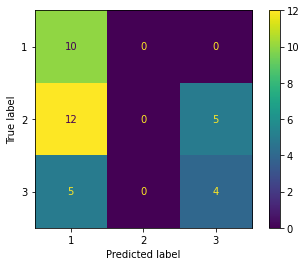

In [152]:
disp_model.plot() 

In [153]:
cm_clf_test=confusion_matrix(Y_test, clf_X_test_pred)

In [154]:
cm_clf_test

array([[10,  0,  0],
       [ 0, 17,  0],
       [ 0,  0,  9]], dtype=int64)

In [155]:
disp_clf = ConfusionMatrixDisplay(confusion_matrix=cm_clf_test, display_labels=model.classes_)

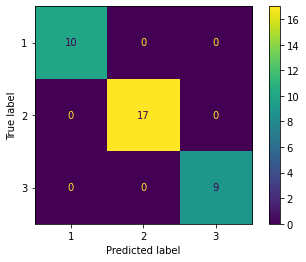

In [156]:
disp_clf.plot() 

In [157]:
cm_knn_test=confusion_matrix(Y_test, knn_X_test_pred)

In [158]:
cm_knn_test

array([[10,  0,  0],
       [ 0, 17,  0],
       [ 1,  1,  7]], dtype=int64)

In [159]:
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn_test, display_labels=model.classes_)

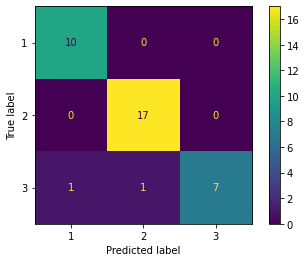

In [160]:
disp_knn.plot()

In [161]:
print(metrics.classification_report(Y_test, clf_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      1.000     1.000     1.000        10
           2      1.000     1.000     1.000        17
           3      1.000     1.000     1.000         9

    accuracy                          1.000        36
   macro avg      1.000     1.000     1.000        36
weighted avg      1.000     1.000     1.000        36



In [162]:
print(metrics.classification_report(Y_test, knn_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      0.909     1.000     0.952        10
           2      0.944     1.000     0.971        17
           3      1.000     0.778     0.875         9

    accuracy                          0.944        36
   macro avg      0.951     0.926     0.933        36
weighted avg      0.949     0.944     0.942        36



In [163]:
print(metrics.classification_report(Y_test, model_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      0.370     1.000     0.541        10
           2      0.000     0.000     0.000        17
           3      0.444     0.444     0.444         9

    accuracy                          0.389        36
   macro avg      0.272     0.481     0.328        36
weighted avg      0.214     0.389     0.261        36



C:\Users\Qwerty\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Qwerty\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Qwerty\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [164]:
#model_cvp=cross_val_predict(model, X_test, Y_test, cv=3, method="predict")

In [165]:
#roc_auc_score(Y_test, model_pred_proba, multi_class='ovr')